In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

In [7]:
class FakeMinimapGenerator():
    def __init__(self):
        self.assets = {}

    def load_image(self, path):
        if path in self.assets:
            return self.assets[path]
        else:
            image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
            self.assets[path] = image
            return self.assets[path]
    
    def place_vision(self, img, cx, cy, r):
        h, w, _ = img.shape
        mask = np.zeros((h, w), np.float32)
        cv2.circle(mask, (cx, cy), r, 1.0, -1)
        mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=3)
        
        img_float = img.astype(np.float32)
        img_float *= (1 + 2 * mask[..., None])
        
        img_result = np.clip(img_float, 0, 255).astype(np.uint8)
        return img_result
    
    def place_image(self, base, img, x, y):
        base_h, base_w = base.shape[:2]
        img_h, img_w = img.shape[:2]
        x1 = max(x, 0)
        y1 = max(y, 0)
        x2 = min(x + img_w, base_w)
        y2 = min(y + img_h, base_h)
    
        # No overlap
        if x1 >= x2 or y1 >= y2:
            return base
    
        # Corresponding region in overlay
        img_x1 = x1 - x
        img_y1 = y1 - y
        img_x2 = img_x1 + (x2 - x1)
        img_y2 = img_y1 + (y2 - y1)
    
        # Convert to float
        base = base.astype(np.float32)
        img = img.astype(np.float32)
    
        # Extract alpha and expand dims
        alpha = img[img_y1:img_y2, img_x1:img_x2, 3] / 255.0
        alpha = alpha[..., None]
    
        # Blend
        base[y1:y2, x1:x2, :] = (
            base[y1:y2, x1:x2, :] * (1 - alpha) +
            img[img_y1:img_y2, img_x1:img_x2, :3] * alpha
        )
    
        return base.astype(np.uint8)
        
    def generate_background(self):
        base_image_name = random.choice(os.listdir('league_icons/minimap/base'))
        base = self.load_image(f'league_icons/minimap/base/{base_image_name}')
        base[:, :, 3] //= 3
        blackboard = np.zeros(shape=[base.shape[0], base.shape[1], 3])
        base = self.place_image(blackboard, base, 0, 0)
        do_atackan_overlay = random.randint(0, 1) == 1
        if do_atackan_overlay:
            overlay_image_name = random.choice(os.listdir('league_icons/minimap/overlay'))
            overlay_image = self.load_image(f'league_icons/minimap/overlay/{overlay_image_name}')
            base = self.place_image(base, overlay_image, 0, 0)
        return base

    def draw_shops(self, base):
        shop_icon = self.load_image('league_icons/misc/shop.png')
        shop_icon = cv2.resize(shop_icon,  None, fx=0.7, fy=0.7)
        base = self.place_image(base, shop_icon, -10, 225)
        base = self.place_image(base, shop_icon, 225, -7)
        return base
        
    def draw_wave(self, base, overlay, start_coord, end_coord, center_coord, travel_distance):
        minion_icon = self.load_image('league_icons/misc/minionmapcircle_ally.png')
        start_x = start_coord[0] * travel_distance + end_coord[0] * (1 - travel_distance)
        start_y = start_coord[1] * travel_distance + end_coord[1] * (1 - travel_distance)
        
        if travel_distance > 0.8:
            target_coord = center_coord
        else:
            target_coord = end_coord

        for i in range(6):
            dt = i / 5
            dt *= 0.2
            t = travel_distance 
            x = target_coord[0] * dt + start_x * (1 - dt)
            y = target_coord[1] * dt + start_y * (1 - dt)
            self.place_image(overlay, minion_icon, x, y)
            self.place_vision(base, x, y, 10)
        return base, overlay

    def draw_minions(self, base, overlay):
        pass 

    def generate(self):
        base = self.generate_background()
        base = self.draw_shops(base)
        
    # draw minions
    # draw flowers
    # draw towers
    # draw wards
    # draw champions
    # draw champion overlays (recalls, teleports, shen ult)
    # draw pings
    # draw camera
    # combine overlay with base
        return cv2.cvtColor(base, cv2.COLOR_BGR2RGB)

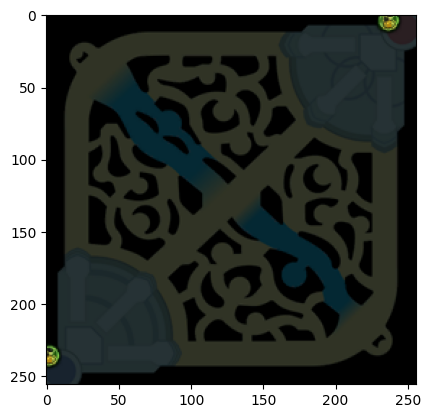

In [8]:
generator = FakeMinimapGenerator()
img = generator.generate()
plt.imshow(img)